# DeFiPy: Python SDK for DeFi Analytics
## Chapter 8: Harnessing Onchain Data with Web3scout

### Listing 8.1: Create a Web3 connection

In [1]:
from web3scout import ConnectW3, ABILoad, Platform, JSONContract

PROVIDER_URL = "https://mainnet.infura.io/v3/9624e3e5c40f4ac3958b79fa5aa2562d"
PLATFORM = Platform.AGNOSTIC
ABI_NAME_UNIV2 = JSONContract.UniswapV2Pair

abi = ABILoad(PLATFORM, ABI_NAME_UNIV2)
connect = ConnectW3(PROVIDER_URL)
connect.apply()

### Listing 8.2: Load ABI

In [2]:
# code block from 8.1

# Load Uniswap V2 Pair contract ABI
abi_loader = ABILoad(
    platform=Platform.AGNOSTIC,
    contract=JSONContract.UniswapV2Pair
)

# Get Web3 connection
w3 = connect.get_w3()

# Retrieve the ABI dictionary
pair_address = "0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc"
pair_contract = abi_loader.apply(w3, pair_address)

name = pair_contract.functions.name().call()
print("Contract name:", name)

Contract name: Uniswap V2


### Listing 8.4: Verify connection

In [3]:
# code block from 8.2

# Get Web3 connection
w3 = connect.get_w3()

# Retrieve the ABI dictionary
pair_address = "0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc"
pair_contract = abi_loader.apply(w3, pair_address)

# 6. Fetch reserve data
reserves = pair_contract.functions.getReserves().call()
print(f"Reserves (block {w3.eth.block_number}):", reserves)

Reserves (block 23729633): [11326144985797, 3496628985225201607277, 1762303739]


### Listing 8.5: Establish connection

In [4]:
from web3scout import JSONContract, Platform, ABILoad, ConnectW3, RetrieveEvents

# Load the Uniswap V2 Pair ABI
abi_loader = ABILoad(Platform.AGNOSTIC, JSONContract.UniswapV2Pair)

# Connect to your target network (e.g., Polygon)
connect = ConnectW3(PROVIDER_URL)
connect.apply()

### Listing: 8.6 Establish connection

In [5]:
# code block from 8.2

# Instantiate RetrieveEvents
r_events = RetrieveEvents(connect, abi_loader)

### Listing 8.7: Query block

In [6]:
# code block from 8.5

latest = r_events.latest_block()
start_block  = latest - 500      # e.g., the last 500 blocks
last_block   = latest

### Listing 8.8: Query block

In [8]:
from web3scout import EventType

# code blocks from 8.6-7

pair_address = "0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc"

# Retrieve events
events = r_events.apply(
    EventType.SWAP, 
    address = pair_address, 
    start_block=start_block, 
    end_block=last_block)

# Convert to DataFrame
r_events.to_dataframe(events).head(2)

,blockNumber,event,address,blockHash,logIndex,transactionHash,transactionIndex,args
0,23729134,Swap,0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc,0x203496354ea334857c29f4640082b6307b4379611f56...,158,0x3670d5fdc7aebafcb06921683fdc812011a7b27b185b...,28,{'sender': '0x51C72848c68a965f66FA7a88855F9f77...
1,23729135,Swap,0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc,0x96c71b867448f4f9f2cf88c74182a0fc530486283ea3...,50,0x653b58753ec1b35605c27e0db8bd66c65357b3dc1ca3...,0,{'sender': '0xfBd4cdB413E45a52E2C8312f670e9cE6...


### Listing 8.9: Handling Other Event Types (ie, MINT, BURN, SYNC)

In [21]:
# code blocks from 8.6-9

# Mints
df_swaps = r_events.to_dataframe(
    r_events.apply(
        EventType.MINT, 
        address = pair_address, 
        start_block=start_block, 
        end_block=last_block)
)

# Burns
df_burns = r_events.to_dataframe(
    r_events.apply(
        EventType.BURN, 
        address = pair_address, 
        start_block=start_block, 
        end_block=last_block)
)

# Syncs
df_syncs = r_events.to_dataframe(
    r_events.apply(
        EventType.SYNC, 
        address = pair_address, 
        start_block=start_block, 
        end_block=last_block)
)

### Listing 8.10: Initializing ExecuteScript see [here](https://defipy.readthedocs.io/en/latest/onchain/testnet_sim_univ2.html)

In [10]:
from defipy import ExecuteScript

contract_dir = 'path/to/solidity/contract'

exe =  ExecuteScript(contract_dir)

### Listing 8.13: Setup environment

In [11]:
from web3scout import RetrieveEvents, ConnectW3, ABILoad, Platform, JSONContract, EventType

# Initialize connection & ABI
connect = ConnectW3(PROVIDER_URL)
connect.apply()
abi_loader = ABILoad(
    platform=Platform.AGNOSTIC,
    contract=JSONContract.UniswapV2Pair
)
r_events   = RetrieveEvents(connect, abi_loader)

### Listing 8.14: Fetch events

In [12]:
def fetch_new_events(
        r_events: RetrieveEvents, 
        address: str, 
        prev_block: int, 
        event_type: EventType):
    
    latest = r_events.latest_block()
    raws   = r_events.apply(event_type, 
                            address, 
                            start_block=prev_block + 1, 
                            end_block=latest)
    df     = r_events.to_dataframe(raws)
    return df, latest

### Listing 8.15: Event rebalancing

In [13]:
from defipy import ExecuteScript

contract_dir = 'path/to/solidity/contract'
rebalance_path = 'path/to/solidity/script/rebalance_script.s.sol'
rpc_url = "https://mainnet.infura.io/v3/xxxxxxxx"

exe =  ExecuteScript(contract_dir)
pair_address = "0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc"
prev_block = r_events.latest_block() - 100

# Fetch new Swap events
swaps_df, last_checked = fetch_new_events(r_events, pair_address, prev_block, EventType.SWAP)

# Filter for high-value trades
large_swaps = swaps_df[swaps_df["args"].apply(lambda d: d["amount1Out"] > 1 * 10**18)]

if not large_swaps.empty:
    print(f"Detected {len(large_swaps)} large swap(s); rebalancing pool…")
        
    # Execute the rebalance script with parameters
    deploy_args = [large_swaps["address"].iloc[0], "--gas-limit", "500000"]
    exe.apply(rebalance_path, rpc_url, verbose=True, args=deploy_args, skip_sim=False)

### Listing 8.16: Retrieve swap events

In [14]:
from web3scout import ConnectW3, ABILoad, RetrieveEvents, Platform, JSONContract, EventType

connect = ConnectW3(PROVIDER_URL)
connect.apply()

abi_loader = ABILoad(Platform.AGNOSTIC, JSONContract.UniswapV2Pair)
r_events = RetrieveEvents(connect, abi_loader)

pair_address = "0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc"

latest = r_events.latest_block()
raw_swaps = r_events.apply(EventType.SWAP, 
                           pair_address, 
                           start_block=latest - 500, 
                           end_block=latest)
df_swaps = r_events.to_dataframe(raw_swaps)

### Listing 8.17: Unpack details

In [15]:
import pandas as pd
df_details = pd.json_normalize(df_swaps["args"])

df_swaps_clean = pd.concat(
    [df_swaps.drop(columns=["args"]), df_details],
    axis=1
)
print(df_swaps_clean.columns)

Index(['blockNumber', 'event', 'address', 'blockHash', 'logIndex',
       'transactionHash', 'transactionIndex', 'sender', 'to', 'amount0In',
       'amount1In', 'amount0Out', 'amount1Out'],
      dtype='object')


### Listing 8.18: Rebuild LP

In [16]:
from defipy import ERC20, UniswapFactory, UniswapExchangeData, UniV3Helper, Join

eth = ERC20("ETH", "0xAAA...")
usdc = ERC20("USDC", "0xBBB...")

user_nm = 'user'
eth_amount = UniV3Helper().dec2gwei(100)
dai_amount = UniV3Helper().dec2gwei(400000)

factory = UniswapFactory("Uniswap V2", "0xFactoryAddress")
exchange_data = UniswapExchangeData(
    tkn0=eth,
    tkn1=usdc,
    symbol="ETH–USDC LP",
    address="0xPoolAddress",
    precision = UniswapExchangeData.TYPE_GWEI
)

lp = factory.deploy(exchange_data)

Join().apply(lp, user_nm, eth_amount, dai_amount)
lp.summary()

Exchange ETH-USDC (ETH–USDC LP)
Reserves: ETH = 100000000000000000000, USDC = 400000000000000000000000
Liquidity: 6324555320336758663997 



### Listing 8.19: Replay swap events

In [17]:
from defipy import Swap

# code-block from 8.18

swap = Swap()

for _, row in df_swaps_clean.iterrows():
    if(row["amount1In"] > 0):
        swap.apply(
            lp, 
            eth, 
            row["sender"], 
            row["amount1In"]
        )

lp.summary()

Exchange ETH-USDC (ETH–USDC LP)
Reserves: ETH = 146126416102167468232, USDC = 274044971511209438657838
Liquidity: 6324555320336758663997 



### Listing 8.20: Inspect LP

In [18]:
# code-block from 8.19

res0 = lp.get_reserve(eth)
res1 = lp.get_reserve(usdc)
liq_tokens = lp.get_liquidity()

print(f"Pool Reserves: {res0 / 1e18} ETH | {res1 / 1e18} USDC")
print(f"Liquidity Tokens Outstanding: {liq_tokens}")

Pool Reserves: 146.12641610216747 ETH | 274044.97151120944 USDC
Liquidity Tokens Outstanding: 6324555320336758663997


### Listing 8.21: Simulate trade

In [19]:
# code-block from 8.20

out = swap.apply(lp, eth, "alice", 1 * 1e18)
print(f"Simulated swap output for 1 ETH: {out / 1e18:.2f} USDC")

Simulated swap output for 1 ETH: 1857.10 USDC


### Listing 8.22: Visualize prices

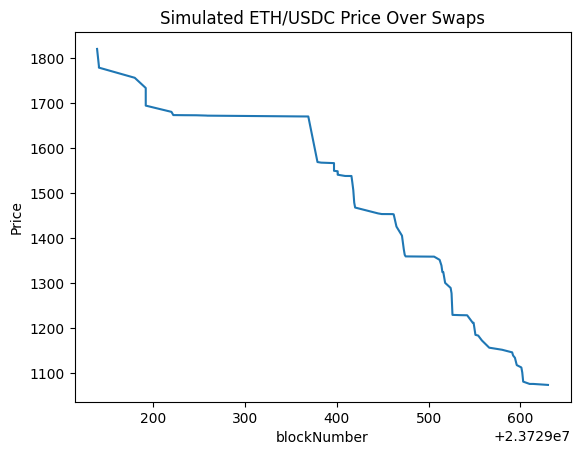

In [20]:
import matplotlib.pyplot as plt

# code-block from 8.21

prices = []

for _, row in df_swaps_clean.iterrows():
    if(row["amount1In"] > 0):
        swap.apply(
            lp, 
            eth, 
            row["sender"], 
            row["amount1In"]
        )
        current_price = lp.get_price(eth)
        prices.append((row["blockNumber"], current_price))

timestamps, price_series = zip(*prices)
plt.plot(timestamps, price_series)
plt.title("Simulated ETH/USDC Price Over Swaps")
plt.xlabel("blockNumber")
plt.ylabel("Price")
plt.show()